# Solving differential equations


## 1. Euler method

## 1.1 First order differential equation

I will  try to solve the following type of differential equation

\\( \frac{\mathrm{d}y}{\mathrm{d}t} = f(t,y)\\)

We know that  \\( \frac{\mathrm{d}y}{\mathrm{d}t} = \frac{y(t+h)-y(t)}{h}\\), then \\( y(t+h) = \frac{\mathrm{d}y}{\mathrm{d}t}h + y(t)\\).

Therefore, we can repetitively iterate this propagation: 

From the value \\( y_n \\) at step \\( n \\), corresponding to the time \\( t \\), we can calculate the value \\( y_{n+1} \\) at step \\( (n+1) \\), corresponding to the time \\( (t+h) \\):

\\( y_{n+1} = y_n + \frac{\mathrm{d}y}{\mathrm{d}t}h \\) which is 

\\( y_{n+1} = y_n + f(t,y_n) h \\)

### Example - Radioactive decay

\\( \dot{y} = -y\\) or

\\( \frac{\mathrm{d}y}{\mathrm{d}t} = f(t,y) = -y\\)

Analytical solution: \\( y(t)=y_0 \exp(-t)\\)

In [104]:
import numpy as np
import matplotlib.pyplot as plt

y = 1 # Starting values

h = 0.1 # Step size

t_values = [0] # Collect data

y_values = [y] # Collect data

nmax = 200 #Number of iteratons

for i in range(1, nmax+1):
    f = - y #Function
    y = y + f * h 
    t_values.append(i*h)
    y_values.append(y)
  



Now we can compare the analytical value with the value we get from Euler method

In [105]:
import numpy as np

t_final = nmax * h
exact = 1*np.exp(-t_final) 

print("Euler:", y_values[-1])
print("Exact:", exact)

Euler: 7.055079108655326e-10
Exact: 2.061153622438558e-09


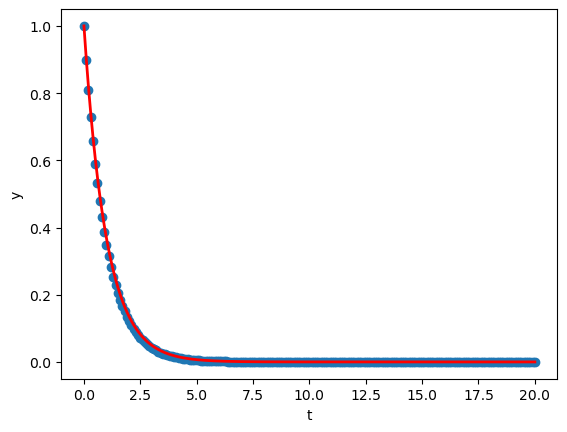

In [106]:
# Visualise the comparison with analytical values
t_exact = np.linspace(0,nmax*h,nmax)
y_exact = 1*np.exp(-t_exact)             # starting y=1

plt.plot(t_exact,y_exact,'red',label='exact')

plt.xlabel('t')
plt.ylabel('y')
plt.scatter(t_values,y_values,label='euler')
plt.show()

The Euler value is smaller than exact.
So Euler decays faster than exact solution.
We can just find the difference to understand a bit more

In [107]:
error = abs(y_values[-1] - np.exp(-nmax*h))
rel_error = error / np.exp(-nmax*h)

print("Absolute error:", error)
print("Relative error:", rel_error)


Absolute error: 1.3556457115730253e-09
Relative error: 0.657712116561771


This much error is expected in the Euler method. We can visulaise it for better understanding by a error vs time graph

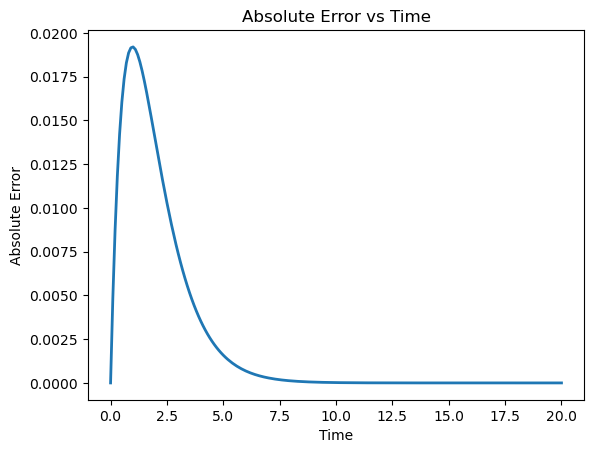

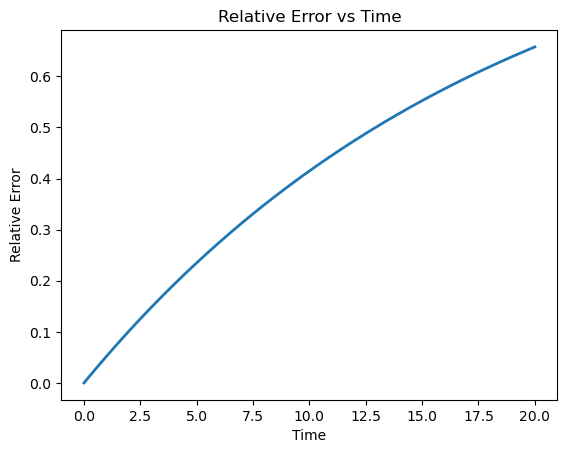

In [108]:
# Computing absolute and relative error 
t_array = np.array(t_values)
y_array = np.array(y_values)

y_exact = np.exp(-t_array)

abs_error = np.abs(y_array - y_exact)
rel_error = abs_error / np.abs(y_exact)



# plotting absolute error

abs_error = np.abs(y_array - y_exact)

plt.plot(t_array, abs_error)
plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Time")
plt.show()


# plotting relative error
plt.plot(t_array, rel_error)
plt.xlabel("Time")
plt.ylabel("Relative Error")
plt.title("Relative Error vs Time")
plt.show()


Here we can find that 
- Absolute error increases gradually with time
- Relative error becomes large at later times
- This is due to the analytical solution approaching zero
- Hence, relative error is less reliable for very small values

We  can try to reduce error by redusing the step size . I think its better to try this and find out. Its better to find the error vs time for different step size together for better understanding.

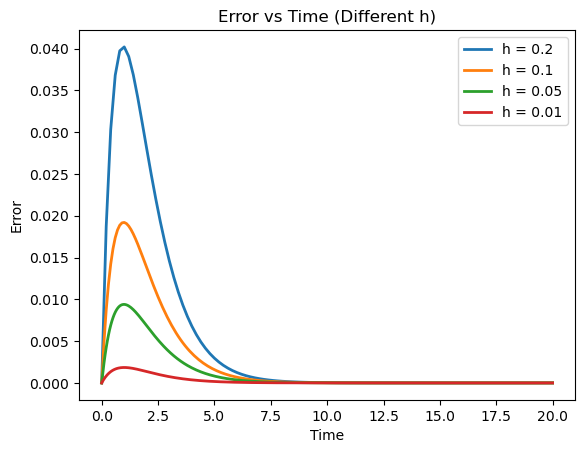

In [109]:
hs = [0.2,0.1,0.05,0.01]
for h in hs: 
    y = 1 # Starting values
    t= 0
    t_values = [t] # Collect data
    y_values = [y] # Collect data

    t_final = 20
    nmax = int(t_final / h)   # keep same final time

   

    for i in range(1, nmax+1):
        f = - y #Function
        y = y + f * h 
        t_values.append(i*h)
        y_values.append(y)
  

    t_array = np.array(t_values)
    y_array = np.array(y_values)

    y_exact = np.exp(-t_array)
    error = np.abs(y_array - y_exact)

    plt.plot(t_array, error, label=f"h = {h}")

plt.xlabel("Time")
plt.ylabel("Error")
plt.title("Error vs Time (Different h)")
plt.legend()
plt.show()

This clearly shows what we needed. The lower value of step size really reduces the error . Now to really understnd the acuuracy of this numerical method we can find the error vs step size plot. 

## Purpose of Error vs Step Size Plot

To evaluate the accuracy of the Euler method, we study how the numerical error depends on the step size (h).

By reducing h and measuring the corresponding error, we can observe the convergence behavior of the method.

A log-log plot of error vs step size reveals a power-law relationship of the form:
    Error ∝ h^p

The slope of this plot gives the order of accuracy (p).

For the Euler method, the slope is approximately 1, confirming that it is a first-order numerical method.

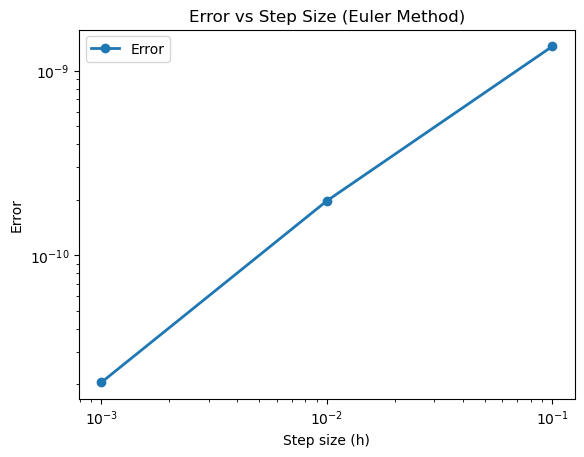

Estimated order of accuracy: 0.9099586507183595
h = 0.1, error = 1.3556457115730253e-09
h = 0.01, error = 1.973970194462904e-10
h = 0.001, error = 2.0522435676441047e-11


In [110]:


# Final time
t_final = 20

# Step sizes
hs = [ 0.1, 0.01, 0.001]

errors = []

for h in hs:
    y = 1  # initial condition
    nmax = int(t_final / h)

    # Euler method loop
    for _ in range(nmax):
        y = y - y * h

    # Exact solution at final time
    exact = np.exp(-t_final)

    # Absolute error at final time
    error = abs(y - exact)
    errors.append(error)

# Convert to arrays for analysis
hs_array = np.array(hs)
errors_array = np.array(errors)

# Log-log plot
plt.loglog(hs_array, errors_array, 'o-', label="Error")

plt.xlabel("Step size (h)")
plt.ylabel("Error")
plt.title("Error vs Step Size (Euler Method)")
plt.legend()
plt.show()

# Compute slope (order of accuracy)
log_h = np.log(hs_array)
log_err = np.log(errors_array)

slope = np.polyfit(log_h, log_err, 1)[0]

print("Estimated order of accuracy:", slope)

# Print values for clarity
for h, err in zip(hs, errors):
    print(f"h = {h}, error = {err}")


We can see
- Error decreases as h decreases
- The log-log plot is approximately linear
- The slope is close to 1, confirming first-order accuracy

### Define a function "EulerODE"

I  made a function for this Euler method as we now know this method is good for calculations with first order accuracy. Lets check if it works.

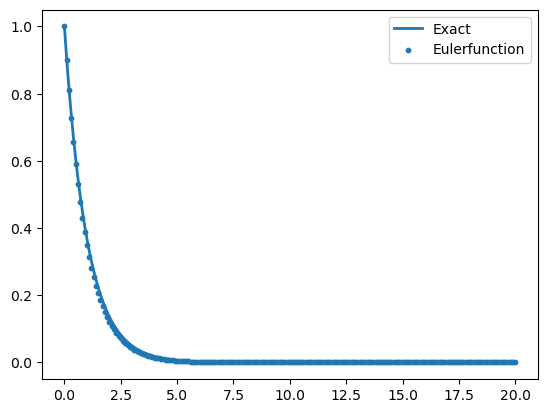

In [111]:
import sys
sys.path.append("../src")
from euler import EulerODE
import numpy as np
import matplotlib.pyplot as plt
def f(t, y):
    return -y
t, y = EulerODE(f, 0, 1, 200, 0.1)
y_exact = np.exp(-t)

plt.plot(t, y_exact, label="Exact")
plt.scatter(t, y, s=10, label="Eulerfunction")

plt.legend()
plt.show()

The numerical solution closely follows the analytic solution which shows that the implementation is correct. We can also do  convergence test and error analysis.

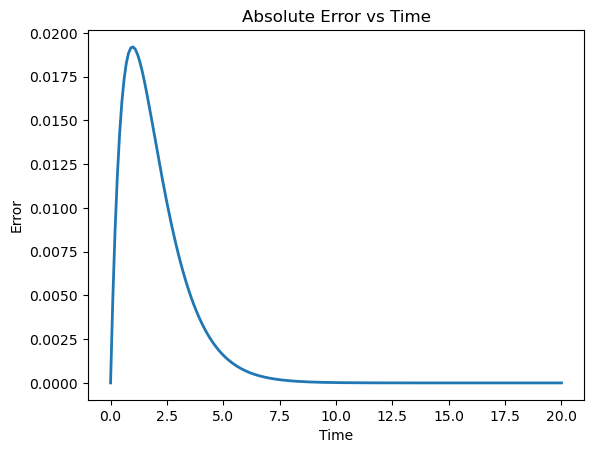

In [112]:
# Error analysis
abs_error = np.abs(y - y_exact)

plt.plot(t, abs_error)
plt.title("Absolute Error vs Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

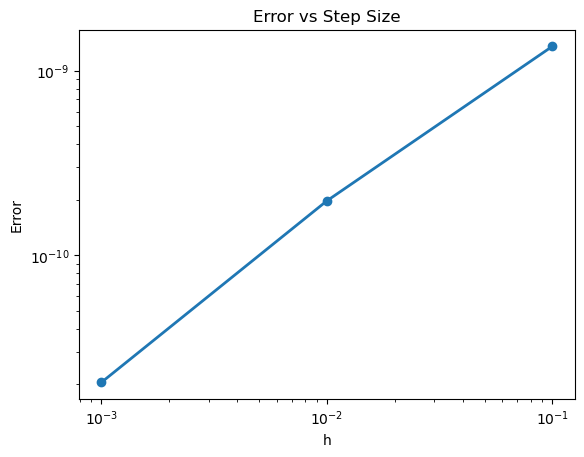

Order: 0.9099586507183595


In [113]:
# convergence or accuracy test
hs = [ 0.1, 0.01, 0.001]
errors = []

for h in hs:
    t, y = EulerODE(f, 0, 1, int(20/h), h)
    exact = np.exp(-20)
    errors.append(abs(y[-1] - exact))

plt.loglog(hs, errors, 'o-')
plt.title("Error vs Step Size")
plt.xlabel("h")
plt.ylabel("Error")
plt.show()
slope = np.polyfit(np.log(hs), np.log(errors), 1)[0]
print("Order:", slope)

The value of slope close to 1, which agrees with the theoretical expectation.
Absolute error does not increase monotonically due to the decaying nature of the solution.

## Conclusion

The function implemented for Euler function is validated against an analytical solution and shown to produce accurate results for small step sizes.
I was able to understand about the errors of Euler method. All the observations confirms that the implementation is mathematically  consistant and correct.
At the same time, the results highlight the limitations of the method, particularly its relatively low accuracy and sensitivity to step size.
